## 0. Mount Google Drive & Set Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys

# ── Adjust this to wherever your project lives in Drive ──────────────────────
PROJECT_ROOT = '/content/drive/MyDrive/project/backend'
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR          = os.path.join(PROJECT_ROOT, 'Data', 'Generated')
CHUNK_A_DIR       = os.path.join(DATA_DIR,    'Chunk1_A')
REPORTS_DIR       = os.path.join(PROJECT_ROOT, 'Reports')
WEIGHTS_DIR       = os.path.join(PROJECT_ROOT, 'Trained_Weights')
NOTEBOOKS_DIR     = os.path.join(PROJECT_ROOT, 'Notebooks')

# Create output directories if they don't exist
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(CHUNK_A_DIR, exist_ok=True)

# Make utils importable
sys.path.insert(0, NOTEBOOKS_DIR)

print('PROJECT_ROOT :', PROJECT_ROOT)
print('DATA_DIR     :', DATA_DIR)
print('REPORTS_DIR  :', REPORTS_DIR)
print('WEIGHTS_DIR  :', WEIGHTS_DIR)

PROJECT_ROOT : /content/drive/MyDrive/project/backend
DATA_DIR     : /content/drive/MyDrive/project/backend/Data/Generated
REPORTS_DIR  : /content/drive/MyDrive/project/backend/Reports
WEIGHTS_DIR  : /content/drive/MyDrive/project/backend/Trained_Weights


## 1. Install Dependencies

In [3]:
!pip install -q transformers datasets sentencepiece protobuf
!pip install -q scikit-learn seaborn matplotlib pandas numpy
!pip install -q keras-nlp tensorflow

## 2. Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, json, time
import numpy  as np
import pandas as pd

import tensorflow as tf
import keras_nlp

from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_auc_score,
)

# Project utilities
from utils import (
    load_data, plot_distribution, plot_accuracy,
    plot_loss, plot_confusion_matrix, plot_precision_recall,
    load_tokenizer,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Device info
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Using GPU: {gpus[0].name}')
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print('Using CPU')

Using GPU: /physical_device:GPU:0


## 3. Configuration

In [38]:
CFG = dict(
    model_name   = 'deberta_v3_base_en',   # keras_nlp preset name
    embedding_name = 'microsoft/deberta-v3-base',
    max_length   = 512,
    batch_size   = 8,          # lower if GPU OOM; use 4 on T4
    epochs       = 5,
    lr           = 2e-5,
    warmup_ratio = 0.1,
    val_split    = 0.15,
    test_split   = 0.10,
    num_labels   = 2,
    weight_decay = 0.01,
)

## 4. Load & Explore Data

In [6]:
VALID_CSV = os.path.join(DATA_DIR, 'valid_dataset.csv')

df = load_data(VALID_CSV)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (932, 4)
Columns: ['INSTRUCTION', 'reasoning', 'RESPONSE', 'label']


,INSTRUCTION,reasoning,RESPONSE,label
0,This math problem has got me stumped: Natalia ...,To find the total number of clips sold in Apri...,72,1
1,Weng earns $12 an hour for babysitting. Yester...,"1. First, we need to calculate Weng's hourly r...",$10,1
2,I'm completely lost with this math problem: Be...,1. Betty initially has half of the money neede...,$5,1


In [7]:
# Basic stats
print('Label distribution:')
print(df['label'].value_counts())
print('\nNull values:')
print(df.isnull().sum())
print('\nDtypes:')
print(df.dtypes)

Label distribution:
label
1    932
Name: count, dtype: int64

Null values:
INSTRUCTION    0
reasoning      0
RESPONSE       0
label          0
dtype: int64

Dtypes:
INSTRUCTION    object
reasoning      object
RESPONSE       object
label           int64
dtype: object


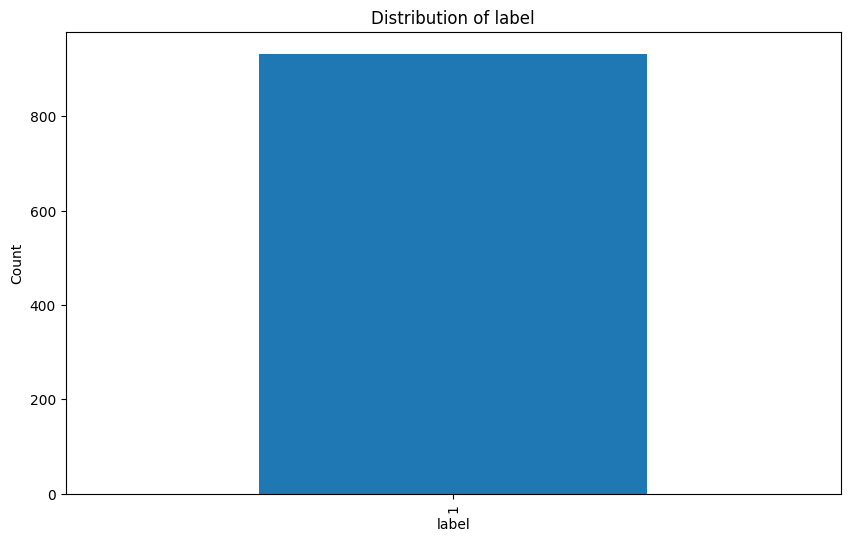

In [8]:
# Label distribution via utils
plot_distribution(df, 'label')

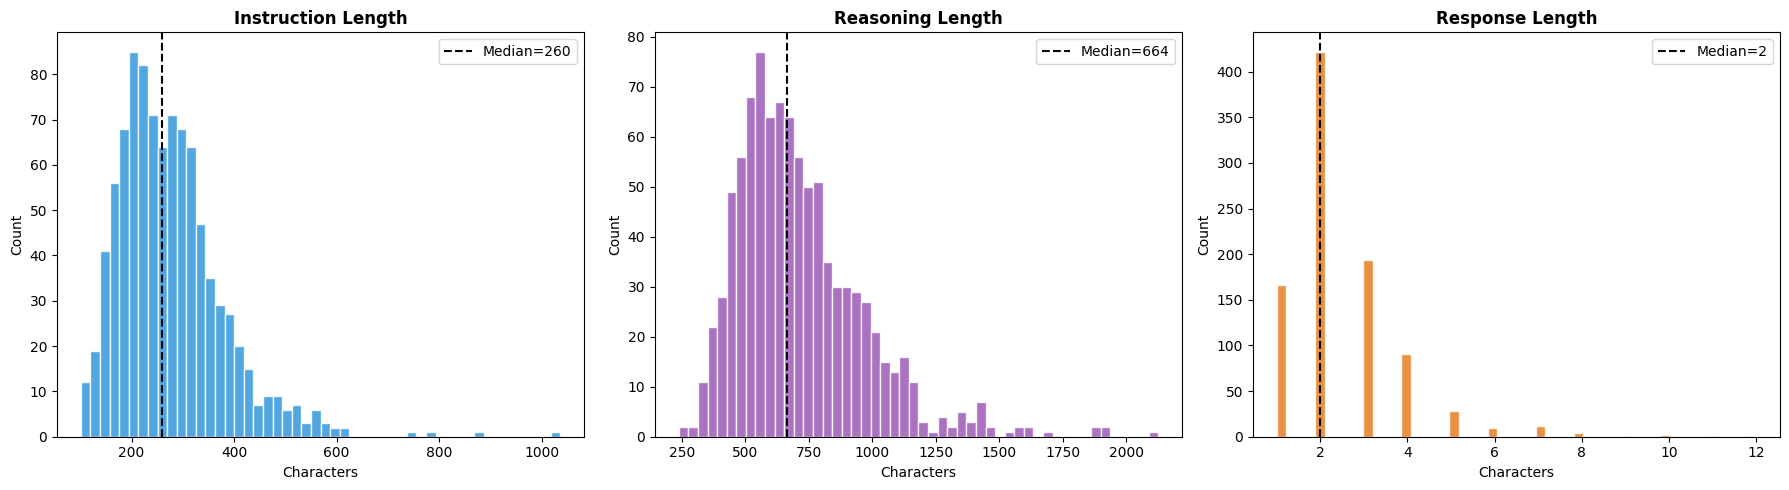

Saved → Reports/fig2_text_lengths.png


In [9]:
# Text length distributions
import matplotlib.pyplot as plt

df['instruction_len'] = df['INSTRUCTION'].astype(str).apply(len)
df['reasoning_len']   = df['reasoning'].astype(str).apply(len)
df['response_len']    = df['RESPONSE'].astype(str).apply(len)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color, title in zip(
    axes,
    ['instruction_len', 'reasoning_len', 'response_len'],
    ['#3498db', '#9b59b6', '#e67e22'],
    ['Instruction Length', 'Reasoning Length', 'Response Length'],
):
    ax.hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='black', linestyle='--', label=f'Median={df[col].median():.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(REPORTS_DIR, 'fig2_text_lengths.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved → Reports/fig2_text_lengths.png')

## 5. Pre-process & Chunk into Chunk1_A

In [10]:
# Drop nulls, reset index
df = df.dropna(subset=['INSTRUCTION', 'reasoning', 'RESPONSE', 'label']).reset_index(drop=True)
df['label'] = df['label'].astype(int)

# Build unified text column: INSTRUCTION \n REASONING \n RESPONSE
df['text'] = (
    df['INSTRUCTION'].astype(str) + '\n' +
    df['reasoning'].astype(str)   + '\n' +
    df['RESPONSE'].astype(str)
)

print(f'Total samples after cleaning: {len(df)}')
print('Sample text (first 200 chars):')
print(df['text'].iloc[0][:200])

Total samples after cleaning: 932
Sample text (first 200 chars):
This math problem has got me stumped: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Can yo


In [11]:
# ── Stratified 70/15/15 split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df[['text', 'label']],
    test_size   = CFG['val_split'] + CFG['test_split'],
    stratify    = df['label'],
    random_state= SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size   = CFG['test_split'] / (CFG['val_split'] + CFG['test_split']),
    stratify    = temp_df['label'],
    random_state= SEED,
)

print(f'Train : {len(train_df):>5} rows')
print(f'Val   : {len(val_df):>5} rows')
print(f'Test  : {len(test_df):>5} rows')

# Save chunk to Chunk1_A folder
train_df.to_csv(os.path.join(CHUNK_A_DIR, 'chunk1a_train.csv'), index=False)
val_df.to_csv  (os.path.join(CHUNK_A_DIR, 'chunk1a_val.csv'),   index=False)
test_df.to_csv (os.path.join(CHUNK_A_DIR, 'chunk1a_test.csv'),  index=False)
print(f'\nChunks saved to: {CHUNK_A_DIR}')

Train :   699 rows
Val   :   139 rows
Test  :    94 rows

Chunks saved to: /content/drive/MyDrive/project/backend/Data/Generated/Chunk1_A


## 6. Tokenizer & TF Dataset

In [26]:
tokenizer = load_tokenizer(CFG["embedding_name"])
print('Tokenizer loaded:', CFG["embedding_name"])
print('Vocab size:', tokenizer.vocab_size)

Tokenizer loaded: microsoft/deberta-v3-base
Vocab size: 128000


In [28]:
def tokenize_texts(texts, labels, tokenizer, max_length, batch_size, shuffle=False):
    """Tokenize texts and return a tf.data.Dataset."""
    token_ids = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='np',  # DebertaV3Tokenizer does not support 'tf'; convert manually below
    )
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            'token_ids':    tf.constant(token_ids['input_ids'],      dtype=tf.int32),
            'padding_mask': tf.constant(token_ids['attention_mask'], dtype=tf.int32),
        },
        tf.constant(list(labels), dtype=tf.int32),
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(texts), seed=SEED)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = tokenize_texts(
    train_df['text'], train_df['label'],
    tokenizer, CFG['max_length'], CFG['batch_size'], shuffle=True
)
val_ds = tokenize_texts(
    val_df['text'], val_df['label'],
    tokenizer, CFG['max_length'], CFG['batch_size']
)
test_ds = tokenize_texts(
    test_df['text'], test_df['label'],
    tokenizer, CFG['max_length'], CFG['batch_size']
)

print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')
print(f'Test  batches : {len(test_ds)}')

Train batches : 88
Val   batches : 18
Test  batches : 12


## 7. Model, Optimizer & Scheduler

In [44]:
def load_model(model_name, num_labels=2):
    model = keras_nlp.models.DebertaV3Classifier.from_preset(model_name, preprocessor=None,num_classes=num_labels)
    return model

model = load_model(CFG['model_name'], num_labels=CFG['num_labels'])
model.summary()

Model: "deberta_v3_text_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deberta_v3_backbone           │ (None, None, 768)         │     183,831,552 │ padding_mask[0][0],        │
│ (DebertaV3Backbone)           │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 768)               │               0 │ deberta_v3_backbone[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 184,423,682 (703.52 MB)

 Trainable params: 184,423,682 (703.52 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
total_steps  = len(train_ds) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])

# Linear warmup + linear decay schedule
lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate = CFG['lr'],
    decay_steps           = total_steps - warmup_steps,
    end_learning_rate     = 0.0,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate = lr_schedule,
    weight_decay  = CFG['weight_decay'],
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer = optimizer,
    loss      = loss_fn,
    metrics   = [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

Total training steps : 440
Warmup steps         : 44


## 8. Training

In [46]:
best_model_path = os.path.join(WEIGHTS_DIR, 'deberta_reasoning_best.keras')

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath          = best_model_path,
        monitor           = 'val_accuracy',
        save_best_only    = True,
        save_weights_only = False,
        verbose           = 1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 3,
        restore_best_weights = True,
        verbose              = 1,
    )
]

history_obj = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CFG['epochs'],
    callbacks       = callbacks,
)

history = {
    'train_loss': history_obj.history['loss'],
    'val_loss':   history_obj.history['val_loss'],
    'train_acc':  history_obj.history['accuracy'],
    'val_acc':    history_obj.history['val_accuracy'],
}

print(f'\nBest Val Accuracy: {max(history["val_acc"]):.4f}')
print(f'Checkpoint: {best_model_path}')

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9784 - loss: 0.0677
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/drive/MyDrive/project/backend/Trained_Weights/deberta_reasoning_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/project/backend/Trained_Weights/deberta_reasoning_best.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.9957 - loss: 0.0166 - val_accuracy: 1.0000 - val_loss: 1.9213e-04
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 4.3655e-04
Epoch 2: val_accuracy did not improve from 1.00000
88/88 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 1.0000 - loss: 3.7557e-04 - val_accuracy: 1.0000 - val_loss: 1.0141e-04
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 2.6366e-04
Epoch 3: val_accuracy did not improve from 1.00000
88/88 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 1.0000 - loss: 2.5168e-04 - val_accuracy: 1.0000 - val_loss: 7.1569e-05
Epoc

## 9. Training Curves

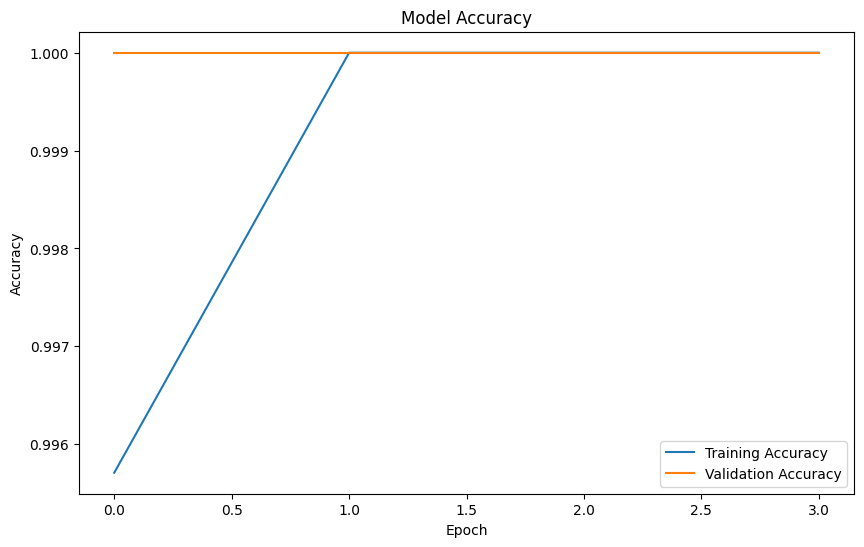

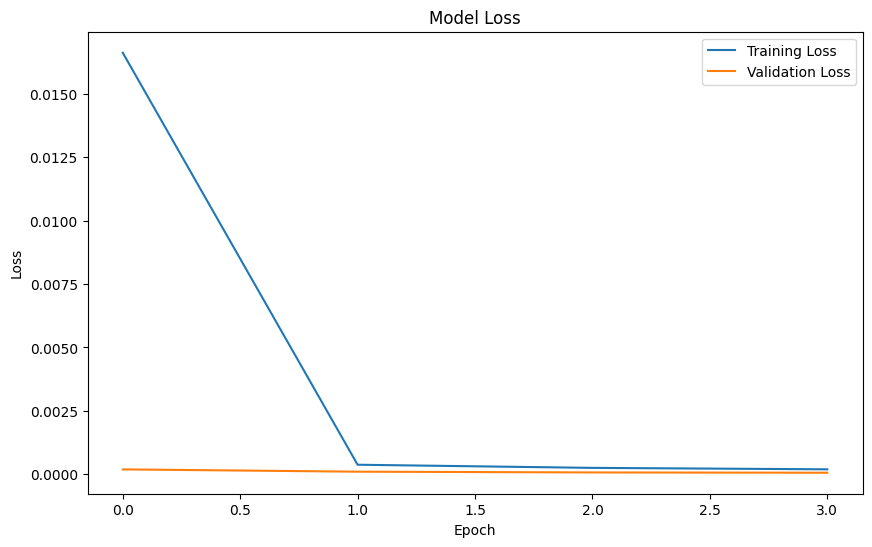

In [47]:
# Training curves via utils
plot_accuracy(history['train_acc'], history['val_acc'])
plot_loss(history['train_loss'],    history['val_loss'])

## 10. Evaluation on Test Set

In [50]:
# Predict on test set
logits_list, labels_list = [], []
for x_batch, y_batch in test_ds:
    logits = model(x_batch, training=False)
    logits_list.append(logits.numpy())
    labels_list.append(y_batch.numpy())

all_logits  = np.concatenate(logits_list, axis=0)
test_labels = np.concatenate(labels_list, axis=0)
test_probs  = tf.nn.softmax(all_logits, axis=-1).numpy()[:, 1]
test_preds  = np.argmax(all_logits, axis=-1)

test_acc = accuracy_score(test_labels, test_preds)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(test_labels, test_probs):.4f}')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, labels=[1], target_names=['Valid']))

Test Accuracy : 1.0000
Test ROC-AUC  : nan

Classification Report:
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00        94

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94



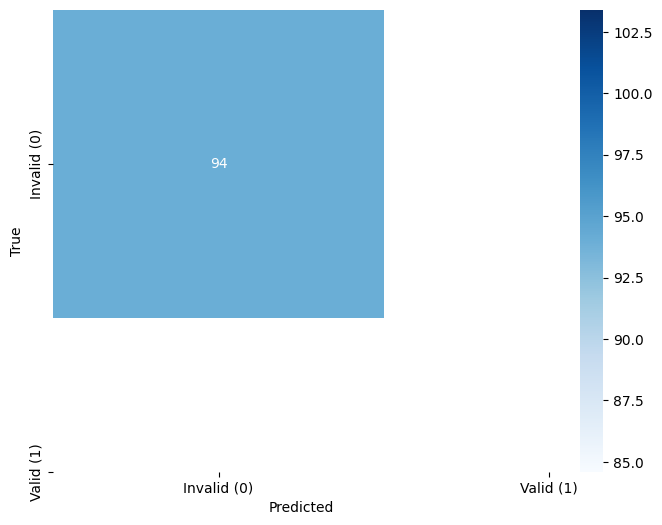

In [51]:
# Confusion matrix via utils
plot_confusion_matrix(test_labels, test_preds, classes=['Invalid (0)', 'Valid (1)'])

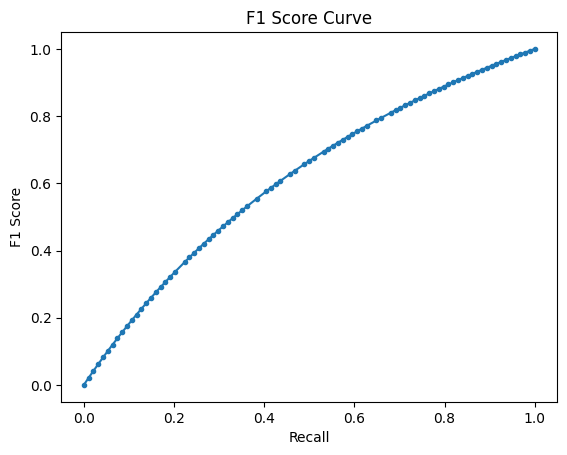

In [52]:
# Precision-Recall / F1 curve via utils
plot_precision_recall(test_labels, test_probs)

## 11. Save Final Weights & Metadata

In [ ]:
# Save full final model in Keras format
final_weights_path = os.path.join(WEIGHTS_DIR, 'deberta_reasoning_final.keras')
model.save(final_weights_path)
print(f'Final model saved → {final_weights_path}')

# Save training history as JSON for future reference
history_path = os.path.join(REPORTS_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump({
        'config' : CFG,
        'history': {k: [float(v) for v in vals] for k, vals in history.items()},
        'test_accuracy' : float(test_acc),
    }, f, indent=2)
print(f'Training log   → {history_path}')

Final model saved → /content/drive/MyDrive/project/backend/Trained_Weights/deberta_reasoning_final.keras
Training log   → /content/drive/MyDrive/project/backend/Reports/training_history.json


## 12. Summary of All Saved Files

In [ ]:
print('=' * 60)
print('REPORTS (figures + logs)')
print('=' * 60)
for f in sorted(os.listdir(REPORTS_DIR)):
    fp = os.path.join(REPORTS_DIR, f)
    print(f'  {f:<45}  {os.path.getsize(fp)/1024:>7.1f} KB')

print()
print('=' * 60)
print('TRAINED WEIGHTS')
print('=' * 60)
for root, dirs, files in os.walk(WEIGHTS_DIR):
    for f in sorted(files):
        fp = os.path.join(root, f)
        rel = os.path.relpath(fp, WEIGHTS_DIR)
        print(f'  {rel:<50}  {os.path.getsize(fp)/1024/1024:>6.1f} MB')

print()
print('=' * 60)
print('CHUNK DATA')
print('=' * 60)
for f in sorted(os.listdir(CHUNK_A_DIR)):
    fp = os.path.join(CHUNK_A_DIR, f)
    print(f'  {f:<45}  {os.path.getsize(fp)/1024:>7.1f} KB')